# XLM-RoBERTa cho PhoNER COVID19
Notebook này thiết lập pipeline huấn luyện mô hình XLM-R trên tập dữ liệu PhoNER_COVID19.

In [4]:
!rm -rf phobert-vietnamese-ner

!git clone https://github.com/HoangCongKhoi/phobert-vietnamese-ner.git

!pip install --upgrade pip setuptools wheel

!pip install --prefer-binary seqeval

%cd phobert-vietnamese-ner

!pip install pytorch-crf peft seqeval datasets

!pip install -U torchao peft

Cloning into 'phobert-vietnamese-ner'...
remote: Enumerating objects: 105, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 105 (delta 44), reused 82 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (105/105), 4.19 MiB | 29.57 MiB/s, done.
Resolving deltas: 100% (44/44), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.4 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
^C
ERROR: Operation cancelled by user
/kaggle/working/phobert-vietnamese-ner
  Using cached pytorch_crf-0.7.2-py3-none-any.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 43.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 41.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found exis

In [5]:
!pip install pytorch-crf peft seqeval datasets

In [6]:
# !pip install -r requirements.txt

In [7]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from torch.optim import AdamW
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

In [8]:
# Cấu hình đường dẫn và thư mục
# Lưu ý: Thay đổi BASE_DIR thành thư mục chứa thư mục dataset PhoNER_COVID19-main nếu chạy trên Kaggle
BASE_DIR = os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "PhoNER_COVID19-main", "data", "word")
OUTPUT_DIR = "./xlmr_phoner_results"
MODEL_NAME = "xlm-roberta-base"


In [9]:
import os

BASE_DIR = os.path.abspath(".")
DATA_DIR = os.path.join(BASE_DIR, "PhoNER_COVID19-main", "data", "word")

if os.path.exists(os.path.join(DATA_DIR, "train_word.conll")):
    print(f"✅ Đã tự động tìm thấy đường dẫn dữ liệu: {DATA_DIR}")
else:
    raise FileNotFoundError("❌ Không tìm thấy thư mục chứa file train_word.conll! Vui lòng kiểm tra lại dữ liệu.")

✅ Đã tự động tìm thấy đường dẫn dữ liệu: /kaggle/working/phobert-vietnamese-ner/PhoNER_COVID19-main/data/word


In [10]:
# Tích hợp Dataloader trực tiếp (không phụ thuộc vào file ngoài)
def read_phoner_file(file_path):
    # Đọc file CoNLL của PhoNER_COVID19
    sentences = []
    labels = []

    with open(file_path, 'r', encoding='utf-8') as f:
        tokens, tags = [], []
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    tokens.append(parts[0])
                    tags.append(parts[1])
        if tokens:
            sentences.append(tokens)
            labels.append(tags)

    return Dataset.from_dict({"tokens": sentences, "ner_tags": labels})

def load_phoner_dataset(data_dir):
    train_ds = read_phoner_file(os.path.join(data_dir, "train_word.conll"))
    dev_ds = read_phoner_file(os.path.join(data_dir, "dev_word.conll"))
    test_ds = read_phoner_file(os.path.join(data_dir, "test_word.conll"))
    return train_ds, dev_ds, test_ds

train_dataset, dev_dataset, test_dataset = load_phoner_dataset(DATA_DIR)

unique_labels = set(tag for tags in train_dataset["ner_tags"] for tag in tags)
label_list = sorted(list(unique_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print(f"✅ Tìm thấy {len(label_list)} nhãn NER trong PhoNER_COVID19.")

✅ Tìm thấy 20 nhãn NER trong PhoNER_COVID19.


In [11]:
# 2. Tokenization & Subword Alignment
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def align_labels_with_tokens(examples):
  input_ids_batch = []
  attention_mask_batch = []
  labels_batch = []
  max_length = 128

  for words, tags in zip(examples["tokens"], examples["ner_tags"]):
    bos_token = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
    subword_ids = [bos_token]
    subword_labels = [-100]

    for word, tag in zip(words, tags):
      word_subwords = tokenizer.encode(word, add_special_tokens=False)

      if not word_subwords:
        continue

      subword_ids.extend(word_subwords)
      subword_labels.append(label2id[tag])
      subword_labels.extend([-100] * (len(word_subwords) - 1))

    eos_token = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id
    subword_ids.append(eos_token)
    subword_labels.append(-100)

    if len(subword_ids) > max_length:
      subword_ids = subword_ids[:max_length]
      subword_labels = subword_labels[:max_length]

    padding_len = max_length - len(subword_ids)
    if padding_len > 0:
      attention_mask = [1] * len(subword_ids) + [0] * padding_len
      subword_ids = subword_ids + [tokenizer.pad_token_id] * padding_len
      subword_labels = subword_labels + [-100] * padding_len
    else:
      attention_mask = [1] * len(subword_ids)

    input_ids_batch.append(subword_ids)
    attention_mask_batch.append(attention_mask)
    labels_batch.append(subword_labels)

  return {
      "input_ids": input_ids_batch,
      "attention_mask": attention_mask_batch,
      "labels": labels_batch,
  }

train_encoded = train_dataset.map(align_labels_with_tokens, batched=True)
dev_encoded = dev_dataset.map(align_labels_with_tokens, batched=True)
test_encoded = test_dataset.map(align_labels_with_tokens, batched=True)

train_encoded.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
dev_encoded.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_encoded.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

BATCH_SIZE = 16
train_loader = DataLoader(train_encoded, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_encoded, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_encoded, batch_size=BATCH_SIZE)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5027 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [12]:
# 3. Model & Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

EPOCHS = 5
best_f1 = 0.0
SAVE_PATH = os.path.join(OUTPUT_DIR, "best_xlmr_model")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps,
)

Using device: cuda


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
import sys
from datasets import config
config.TORCHVISION_AVAILABLE = False

# 4. Training Loop
for epoch in range(EPOCHS):
  # --- TRAIN ---
  model.train()
  total_train_loss = 0

  train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

  for batch in train_pbar:
    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    outputs = model(
        input_ids=input_ids, attention_mask=attention_mask, labels=labels
    )
    loss = outputs.loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    total_train_loss += loss.item()
    train_pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

  avg_train_loss = total_train_loss / len(train_loader)

  # --- VALIDATION ---
  model.eval()
  total_val_loss = 0
  val_preds, val_labels = [], []

  val_pbar = tqdm(dev_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [ Valid ]", leave=False)

  with torch.no_grad():
    for batch in val_pbar:
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      outputs = model(
          input_ids=input_ids, attention_mask=attention_mask, labels=labels
      )
      loss = outputs.loss
      total_val_loss += loss.item()

      logits = outputs.logits.detach().cpu().numpy()
      label_ids = labels.to("cpu").numpy()
      preds = np.argmax(logits, axis=2)

      for pred, label in zip(preds, label_ids):
        val_preds.append([id2label[p] for (p, l) in zip(pred, label) if l != -100])
        val_labels.append([id2label[l] for (p, l) in zip(pred, label) if l != -100])

  avg_val_loss = total_val_loss / len(dev_loader)

  val_f1 = f1_score(val_labels, val_preds)
  val_precision = precision_score(val_labels, val_preds)
  val_recall = recall_score(val_labels, val_preds)

  print(
      f"Epoch {epoch+1}/{EPOCHS} | "
      f"Train Loss: {avg_train_loss:.4f} | "
      f"Val Loss: {avg_val_loss:.4f} | "
      f"Val Precision: {val_precision:.4f} | "
      f"Val Recall: {val_recall:.4f} | "
      f"Val F1: {val_f1:.4f}\n"
  )
  if val_f1 > best_f1:
      best_f1 = val_f1
      print(f"F1 cải thiện lên {best_f1:.4f}! Đang lưu model tốt nhất vào: {SAVE_PATH}...")
      model.save_pretrained(SAVE_PATH)
      tokenizer.save_pretrained(SAVE_PATH)

Epoch 1/5 [Train]:   0%|          | 0/315 [00:00<?, ?it/s]

Epoch 1/5 [ Valid ]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 0.5846 | Val Loss: 0.1043 | Val Precision: 0.8910 | Val Recall: 0.9109 | Val F1: 0.9008

F1 cải thiện lên 0.9008! Đang lưu model tốt nhất vào: ./xlmr_phoner_results/best_xlmr_model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/315 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/315 [00:00<?, ?it/s]

Epoch 5/5 [ Valid ]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 5/5 | Train Loss: 0.0157 | Val Loss: 0.0736 | Val Precision: 0.9450 | Val Recall: 0.9551 | Val F1: 0.9500

F1 cải thiện lên 0.9500! Đang lưu model tốt nhất vào: ./xlmr_phoner_results/best_xlmr_model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
# 5. Evaluate on Test Set
print("Đang đánh giá trên tập TEST...")
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
  for batch in tqdm(test_loader, desc="[ Testing ]"):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits.detach().cpu().numpy()
    label_ids = labels.to("cpu").numpy()
    preds = np.argmax(logits, axis=2)

    for pred, label in zip(preds, label_ids):
      test_preds.append([id2label[p] for (p, l) in zip(pred, label) if l != -100])
      test_labels.append([id2label[l] for (p, l) in zip(pred, label) if l != -100])

report = classification_report(test_labels, test_preds)
print("\n--- REPORT (TEST SET) ---")
print(report)

Đang đánh giá trên tập TEST...


[ Testing ]:   0%|          | 0/188 [00:00<?, ?it/s]


--- REPORT (TEST SET) ---
                     precision    recall  f1-score   support

               DATE       0.98      0.99      0.99      1641
         PATIENT_ID       0.98      0.99      0.98      1953
SYMPTOM_AND_DISEASE       0.88      0.88      0.88      1125
     TRANSPORTATION       0.97      0.96      0.97       193
           LOCATION       0.93      0.94      0.94      4398
                AGE       0.96      0.97      0.97       566
       ORGANIZATION       0.83      0.88      0.86       767
             GENDER       0.95      0.98      0.97       447
               NAME       0.90      0.92      0.91       309
                JOB       0.65      0.72      0.68       173

          micro avg       0.93      0.95      0.94     11572
          macro avg       0.93      0.95      0.94     11572



/tmp/ipykernel_58/1204545476.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1-Score", y="Entity", data=df_res, palette="crest")


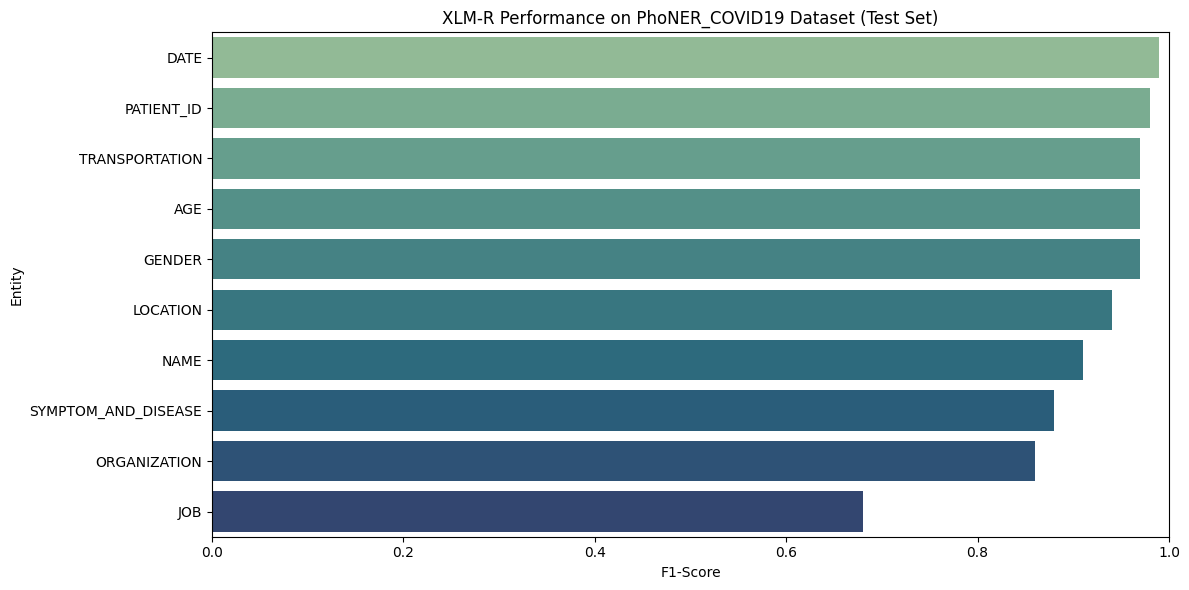

In [16]:
# 6. Trực quan hóa kết quả
lines = report.strip().split("\n")
entities, f1_scores = [], []
for line in lines[2:]:
  parts = line.strip().split()
  if len(parts) >= 4 and parts[0] not in ["micro", "macro", "weighted", "avg"]:
    try:
      entity_name = parts[0]
      f1_val = float(parts[3])
      entities.append(entity_name)
      f1_scores.append(f1_val)
    except ValueError:
      continue

df_res = pd.DataFrame({"Entity": entities, "F1-Score": f1_scores}).sort_values(
    by="F1-Score", ascending=False
)

plt.figure(figsize=(12, 6))
sns.barplot(x="F1-Score", y="Entity", data=df_res, palette="crest")
plt.title("XLM-R Performance on PhoNER_COVID19 Dataset (Test Set)")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig("phoner_covid19_xlmr_f1_scores.png", dpi=300)
plt.show()

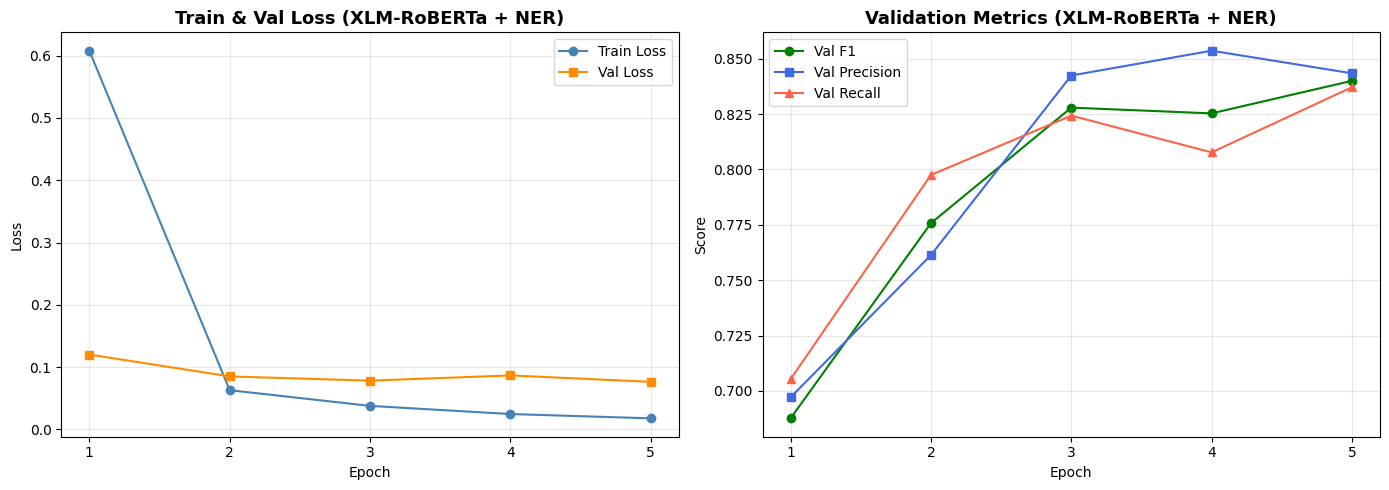

✅ Đã lưu: xlmr_training_curves.png


In [17]:
# 6. Vẽ biểu đồ Training Curves (XLM-RoBERTa)
epochs_list = list(range(1, EPOCHS + 1))
train_losses  = [0.6080, 0.0630, 0.0378, 0.0247, 0.0178]
val_losses    = [0.1202, 0.0851, 0.0783, 0.0867, 0.0764]
val_f1s       = [0.6876, 0.7757, 0.8279, 0.8253, 0.8400]
val_precisions= [0.6971, 0.7613, 0.8424, 0.8536, 0.8434]
val_recalls   = [0.7053, 0.7975, 0.8243, 0.8077, 0.8371]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axs[0].plot(epochs_list, train_losses, 'o-', label='Train Loss', color='steelblue')
axs[0].plot(epochs_list, val_losses,   's-', label='Val Loss',   color='darkorange')
axs[0].set_title('Train & Val Loss (XLM-RoBERTa + NER)', fontsize=13, weight='bold')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_xticks(epochs_list)
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Validation metric curves
axs[1].plot(epochs_list, val_f1s,        'o-', label='Val F1',        color='green')
axs[1].plot(epochs_list, val_precisions, 's-', label='Val Precision', color='royalblue')
axs[1].plot(epochs_list, val_recalls,    '^-', label='Val Recall',    color='tomato')
axs[1].set_title('Validation Metrics (XLM-RoBERTa + NER)', fontsize=13, weight='bold')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Score')
axs[1].set_xticks(epochs_list)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xlmr_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: xlmr_training_curves.png')

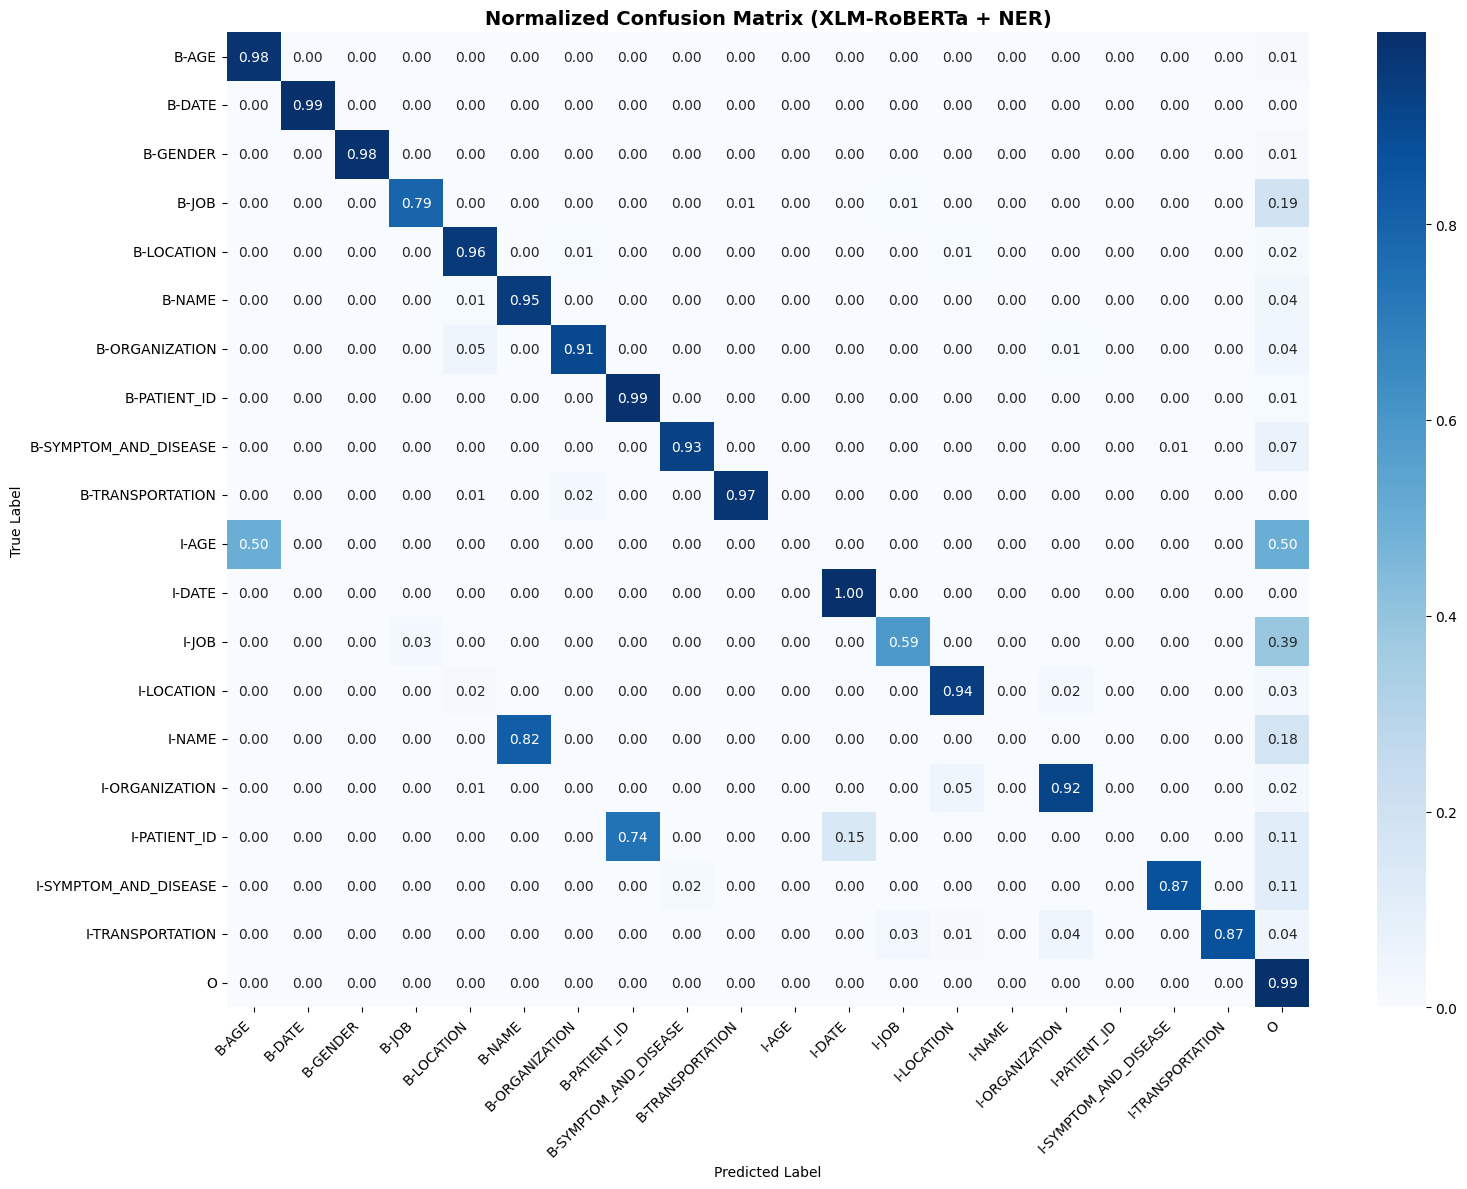

✅ Đã lưu: xlmr_confusion_matrix.png


In [18]:
# 7. Vẽ Normalized Confusion Matrix (XLM-RoBERTa)
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

# Flatten danh sách nhãn từ test_preds / test_labels (list of lists)
flat_test_preds  = [p for seq in test_preds  for p in seq]
flat_test_labels = [l for seq in test_labels for l in seq]

labels_order = label_list  # thứ tự nhãn đã được sắp xếp khi load dataset
cm = sk_confusion_matrix(flat_test_labels, flat_test_preds,
                         labels=labels_order, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=labels_order, yticklabels=labels_order
)
plt.title('Normalized Confusion Matrix (XLM-RoBERTa + NER)', fontsize=14, weight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('xlmr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: xlmr_confusion_matrix.png')